# Lecture A02: From Counting to Continuous Posteriors

Companion notebook for [[Lecture A02]]. Prerequisite: [[A01_Introduction_to_Bayesian_Workflow]].

**Part 1** — Lecture walkthrough: d4-to-continuous convergence, Beta distribution, probability density, posterior properties, posterior predictive distribution, point estimate vs full posterior, sampling approximation, prior predictive simulation

**Part 2** — Applied exercises with Slovenian data: real estate posterior predictive, forensic audio anomaly prediction, small-sample municipality posteriors, crime rate prediction, point estimate vs full posterior for price index

**Convention:** 89% credible intervals (McElreath default).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

# Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 150,
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

# Color palette
C_PRIOR = "#9ca3af"
C_POSTERIOR = "#2563eb"
C_LIKELIHOOD = "#dc2626"
C_DATA = "#059669"
C_ACCENT = "#d97706"
C_POINT = "#111827"

DATA_DIR = Path("../data")
CI_LEVEL = 0.89
N_SAMPLES = 10_000

---

# Part 1: Lecture Walkthrough

## 1. From Finite Dice to the Continuous Globe

In A01 we used a d4 (5 candidate values for $p$). Now we increase the resolution: d4, d10, d20, and finally the continuous Beta. The counting logic is preserved at every step; the bars just get narrower until they become a smooth curve.

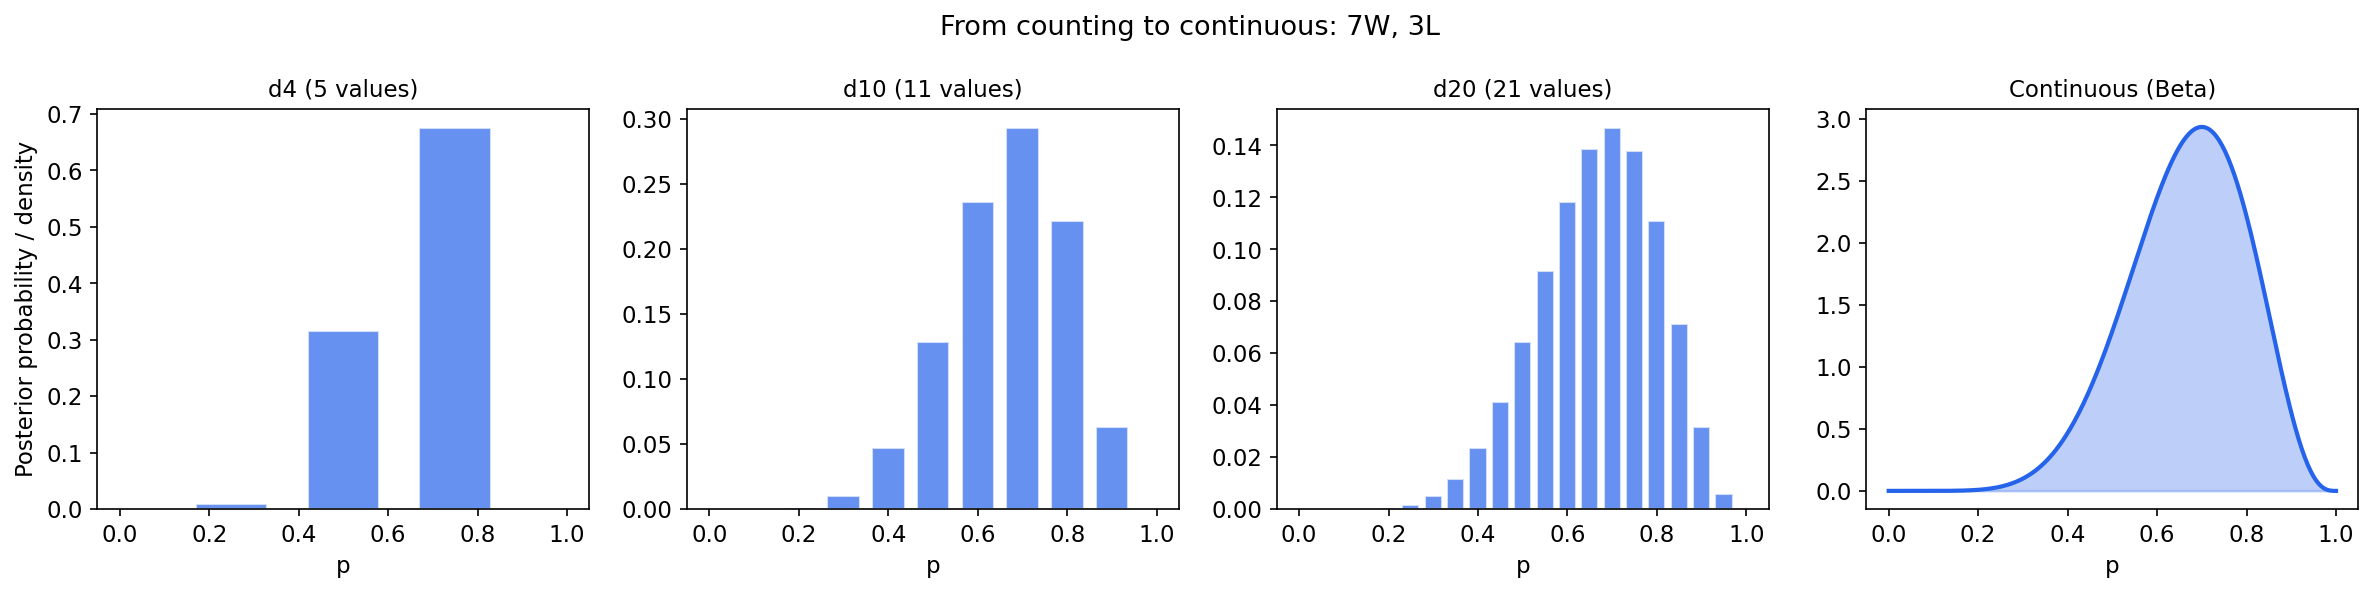

In [2]:
def plot_discrete_to_continuous(n_water: int = 7, n_land: int = 3) -> None:
    """Show progression from d4 to d10 to d20 to continuous Beta posterior."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    sides_list = [4, 10, 20, 200]
    titles = ["d4 (5 values)", "d10 (11 values)", "d20 (21 values)", "Continuous (Beta)"]

    for ax, n_sides, title in zip(axes, sides_list, titles):
        p_vals = np.linspace(0, 1, n_sides + 1)
        unnorm = p_vals**n_water * (1 - p_vals)**n_land
        if unnorm.sum() > 0:
            posterior = unnorm / unnorm.sum()
        else:
            posterior = unnorm

        if n_sides < 200:
            ax.bar(p_vals, posterior, width=1 / (n_sides + 1) * 0.8,
                   color=C_POSTERIOR, alpha=0.7, edgecolor="white")
        else:
            beta_dist = stats.beta(n_water + 1, n_land + 1)
            p_fine = np.linspace(0, 1, 300)
            ax.fill_between(p_fine, beta_dist.pdf(p_fine), alpha=0.3, color=C_POSTERIOR)
            ax.plot(p_fine, beta_dist.pdf(p_fine), color=C_POSTERIOR, linewidth=2)

        ax.set_title(title, fontsize=11)
        ax.set_xlabel("p")
        ax.set_xlim(-0.05, 1.05)

    axes[0].set_ylabel("Posterior probability / density")
    plt.suptitle(f"From counting to continuous: {n_water}W, {n_land}L", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_discrete_to_continuous(n_water=7, n_land=3)

## 2. The Beta Distribution

The continuous posterior for the globe model is $\text{Beta}(\alpha, \beta)$ where $\alpha = W + 1$, $\beta = L + 1$ (flat prior).

$$\text{Beta}(p \mid \alpha, \beta) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)} \cdot p^{\alpha-1}(1-p)^{\beta-1}$$

When you write `pm.Beta("p", alpha=8, beta=4)`, you encode information equivalent to 7W and 3L observations.

In [3]:
# Beta(8, 4) from 7W, 3L
posterior = stats.beta(a=8, b=4)

print(f"Posterior mean:   {posterior.mean():.4f}")
print(f"Posterior mode:   {(8 - 1) / (8 + 4 - 2):.4f}")  # (alpha-1)/(alpha+beta-2)
print(f"Posterior std:    {posterior.std():.4f}")

# Multiple interval widths
for pct in [0.50, 0.89, 0.95]:
    lo, hi = posterior.ppf((1 - pct) / 2), posterior.ppf(1 - (1 - pct) / 2)
    print(f"{pct*100:.0f}% interval: [{lo:.3f}, {hi:.3f}]")

Posterior mean:   0.6667
Posterior mode:   0.7000
Posterior std:    0.1307
50% interval: [0.580, 0.764]
89% interval: [0.442, 0.861]
95% interval: [0.390, 0.891]


## 3. Probability Density vs Probability

The y-axis on a continuous posterior is **density**, not probability. Density can exceed 1.0. The probability that $p$ falls in $[a, b]$ is the **area** under the curve between $a$ and $b$.

Analogy: population density. Ljubljana has ~2,000 people/km2. That is not a count; you multiply by area to get a count.

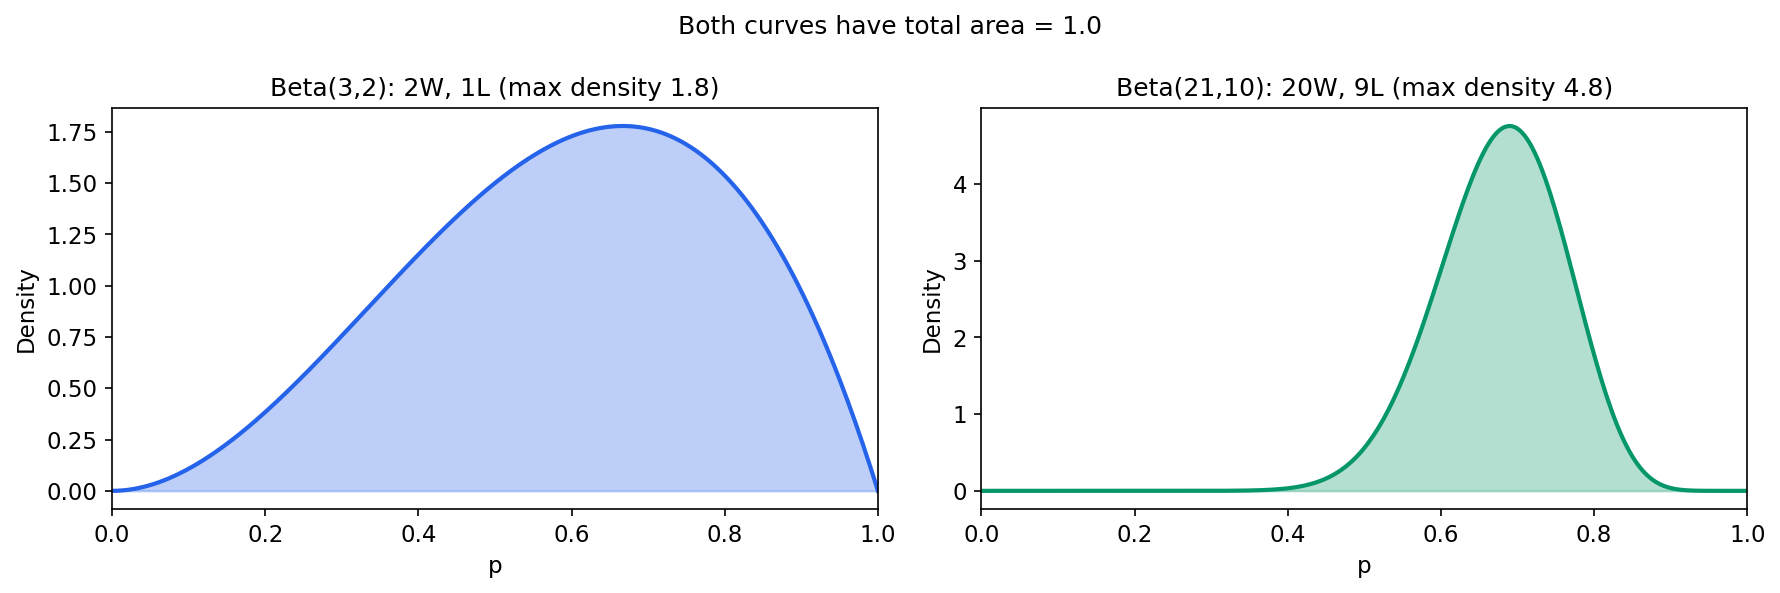

Area under Beta(3,2):   1.0000
Area under Beta(21,10): 1.0000


In [4]:
# Density can exceed 1: a narrow posterior has high peak but same total area
p = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Few observations: broad, low density
dist_few = stats.beta(3, 2)
axes[0].fill_between(p, dist_few.pdf(p), alpha=0.3, color=C_POSTERIOR)
axes[0].plot(p, dist_few.pdf(p), color=C_POSTERIOR, linewidth=2)
axes[0].set_title(f"Beta(3,2): 2W, 1L (max density {dist_few.pdf(p).max():.1f})")
axes[0].set_ylabel("Density")
axes[0].set_xlabel("p")

# Many observations: narrow, high density
dist_many = stats.beta(21, 10)
axes[1].fill_between(p, dist_many.pdf(p), alpha=0.3, color=C_DATA)
axes[1].plot(p, dist_many.pdf(p), color=C_DATA, linewidth=2)
axes[1].set_title(f"Beta(21,10): 20W, 9L (max density {dist_many.pdf(p).max():.1f})")
axes[1].set_ylabel("Density")
axes[1].set_xlabel("p")

for ax in axes:
    ax.set_xlim(0, 1)

plt.suptitle("Both curves have total area = 1.0", fontsize=12)
plt.tight_layout()
plt.show()

# Verify
print(f"Area under Beta(3,2):   {dist_few.cdf(1) - dist_few.cdf(0):.4f}")
print(f"Area under Beta(21,10): {dist_many.cdf(1) - dist_many.cdf(0):.4f}")

## 4. Four Properties of the Posterior

1. **No minimum sample size.** A posterior from 1 observation is valid. Wide, but valid.
2. **Shape embodies sample size.** Narrow = lots of data. Broad = little data.
3. **The distribution IS the estimate.** Point estimates are lossy compression.
4. **No one true interval.** 89%, 95%, 50% are all conventions. Report alongside the full distribution.

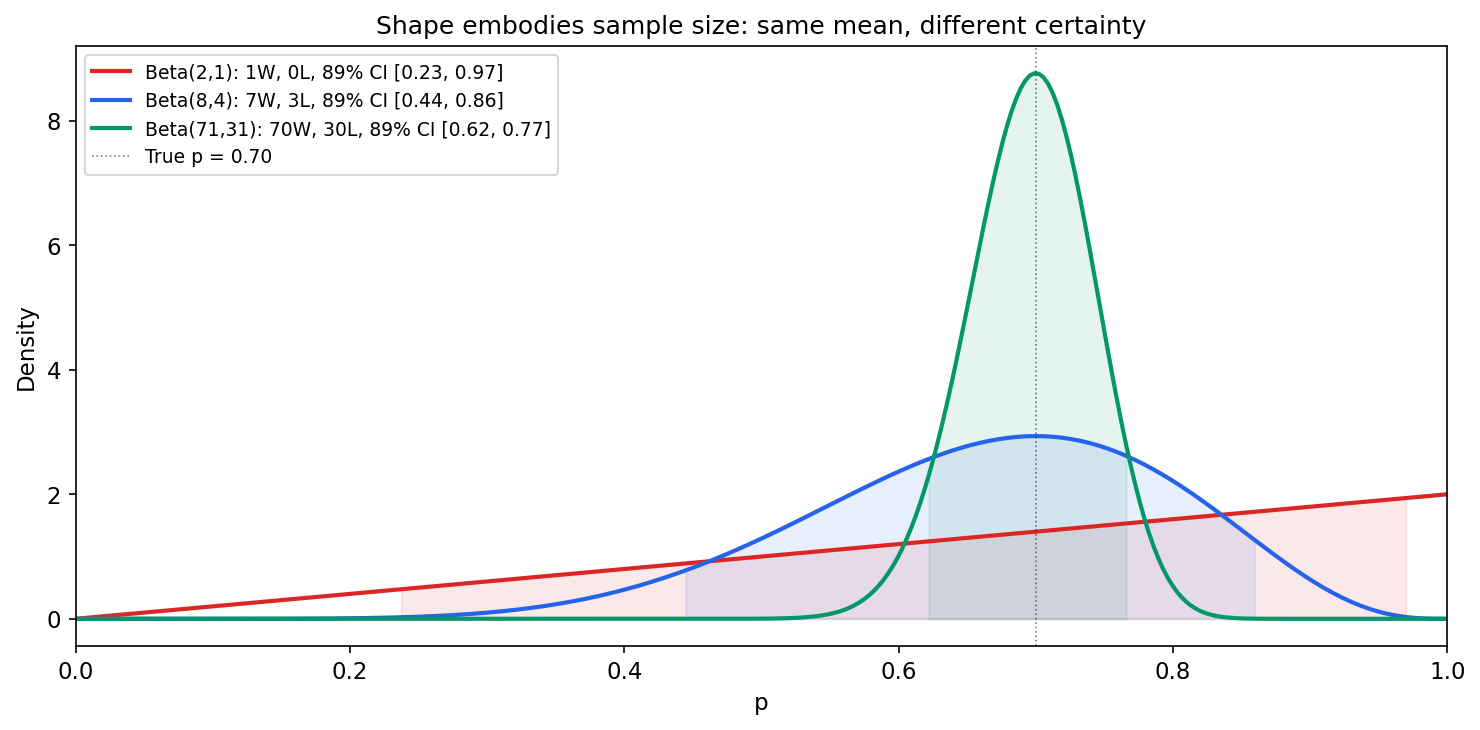

In [5]:
# Properties 1 & 2: shape encodes sample size
fig, ax = plt.subplots(figsize=(10, 5))
p_grid = np.linspace(0, 1, 300)

cases = [
    ("Beta(2,1): 1W, 0L", 2, 1, C_LIKELIHOOD),
    ("Beta(8,4): 7W, 3L", 8, 4, C_POSTERIOR),
    ("Beta(71,31): 70W, 30L", 71, 31, C_DATA),
]

for label, a, b, color in cases:
    dist = stats.beta(a, b)
    ci_lo, ci_hi = dist.ppf(0.055), dist.ppf(0.945)
    ax.plot(p_grid, dist.pdf(p_grid), linewidth=2, color=color,
            label=f"{label}, 89% CI [{ci_lo:.2f}, {ci_hi:.2f}]")
    mask = (p_grid >= ci_lo) & (p_grid <= ci_hi)
    ax.fill_between(p_grid[mask], dist.pdf(p_grid[mask]), alpha=0.1, color=color)

ax.axvline(0.7, color="black", linestyle=":", linewidth=0.8, alpha=0.5, label="True p = 0.70")
ax.set_xlabel("p")
ax.set_ylabel("Density")
ax.set_title("Shape embodies sample size: same mean, different certainty")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 5. Posterior Predictive Distribution

The central technique of applied Bayesian statistics. Three steps:

1. **Sample** $p$ values from the posterior (proportional to density)
2. **Simulate** new data for each sampled $p$ through the generative model
3. **Collect** all simulated outcomes

$$P(W_{\text{new}} = w) = \int_0^1 \text{Binomial}(w \mid n, p) \cdot \text{Beta}(p \mid \alpha, \beta) \, dp$$

Sampling replaces this integral. Works for any model, not just conjugate ones.

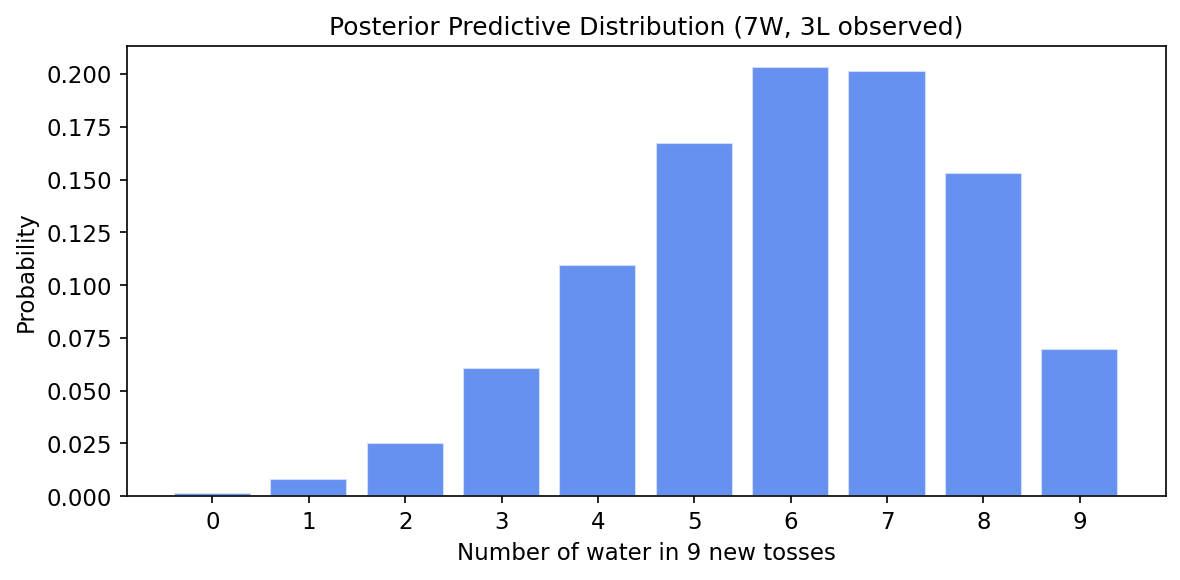

Expected water: 6.0
89% prediction interval: [3, 9]


In [6]:
def posterior_predictive(
    n_water: int,
    n_land: int,
    n_new: int,
    n_samples: int = N_SAMPLES,
    seed: int = SEED,
) -> np.ndarray:
    """Generate posterior predictive distribution via sampling.

    Args:
        n_water: Observed water count.
        n_land: Observed land count.
        n_new: Number of new observations to predict.
        n_samples: Number of posterior samples.
        seed: Random seed.

    Returns:
        Array of predicted counts (length = n_samples).
    """
    rng = np.random.default_rng(seed)

    # Step 1: sample p from posterior
    posterior = stats.beta(n_water + 1, n_land + 1)
    p_samples = posterior.rvs(size=n_samples, random_state=rng)

    # Step 2 + 3: simulate and collect
    return rng.binomial(n=n_new, p=p_samples)


# Globe tossing: predict 9 new tosses after observing 7W, 3L
predictions = posterior_predictive(n_water=7, n_land=3, n_new=9)

fig, ax = plt.subplots(figsize=(8, 4))
counts = np.bincount(predictions, minlength=10)
probs = counts / counts.sum()
ax.bar(range(10), probs, color=C_POSTERIOR, alpha=0.7, edgecolor="white")
ax.set_xlabel("Number of water in 9 new tosses")
ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive Distribution (7W, 3L observed)")
ax.set_xticks(range(10))
plt.tight_layout()
plt.show()

print(f"Expected water: {predictions.mean():.1f}")
print(f"89% prediction interval: [{np.percentile(predictions, 5.5):.0f}, "
      f"{np.percentile(predictions, 94.5):.0f}]")

## 6. Point Estimate vs Full Posterior: "Summarize Last"

The most common mistake in applied Bayesian work. Plugging the posterior mean into the generative model discards parameter uncertainty, producing overconfident predictions.

McElreath: "If you are about to take a mean, ask if you have more calculations to do. If yes, stop."

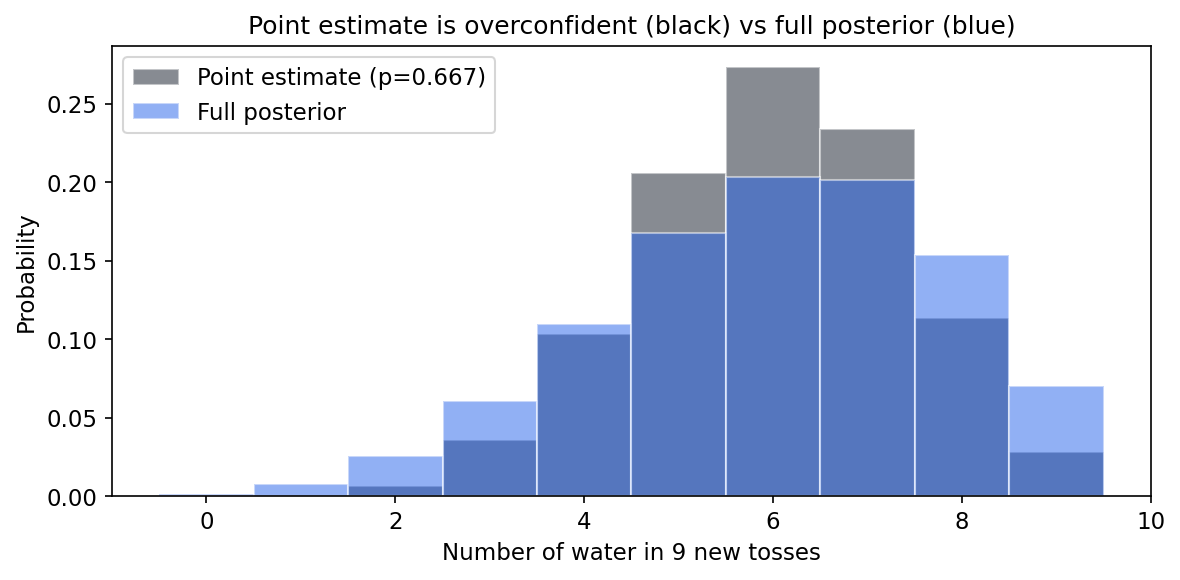

Point estimate std: 1.41
Full posterior std: 1.80
Full posterior is 1.3x wider


In [7]:
def compare_point_vs_full(
    n_water: int = 7,
    n_land: int = 3,
    n_new: int = 9,
    n_samples: int = N_SAMPLES,
    seed: int = SEED,
) -> None:
    """Compare predictions from point estimate vs full posterior."""
    rng = np.random.default_rng(seed)
    posterior = stats.beta(n_water + 1, n_land + 1)

    # Full posterior predictive
    p_samples = posterior.rvs(size=n_samples, random_state=rng)
    full_pred = rng.binomial(n=n_new, p=p_samples)

    # Point estimate predictive
    p_mean = posterior.mean()
    point_pred = rng.binomial(n=n_new, p=p_mean, size=n_samples)

    fig, ax = plt.subplots(figsize=(8, 4))
    bins = np.arange(-0.5, n_new + 1.5, 1)

    ax.hist(point_pred, bins=bins, density=True, alpha=0.5,
            color=C_POINT, label=f"Point estimate (p={p_mean:.3f})", edgecolor="white")
    ax.hist(full_pred, bins=bins, density=True, alpha=0.5,
            color=C_POSTERIOR, label="Full posterior", edgecolor="white")

    ax.set_xlabel(f"Number of water in {n_new} new tosses")
    ax.set_ylabel("Probability")
    ax.set_title("Point estimate is overconfident (black) vs full posterior (blue)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Point estimate std: {point_pred.std():.2f}")
    print(f"Full posterior std: {full_pred.std():.2f}")
    print(f"Full posterior is {full_pred.std() / point_pred.std():.1f}x wider")

compare_point_vs_full()

## 7. Sampling Approximation

For complex models, analytical posteriors do not exist. MCMC generates samples instead. Once you have samples, all downstream computations are identical. More samples = better approximation.

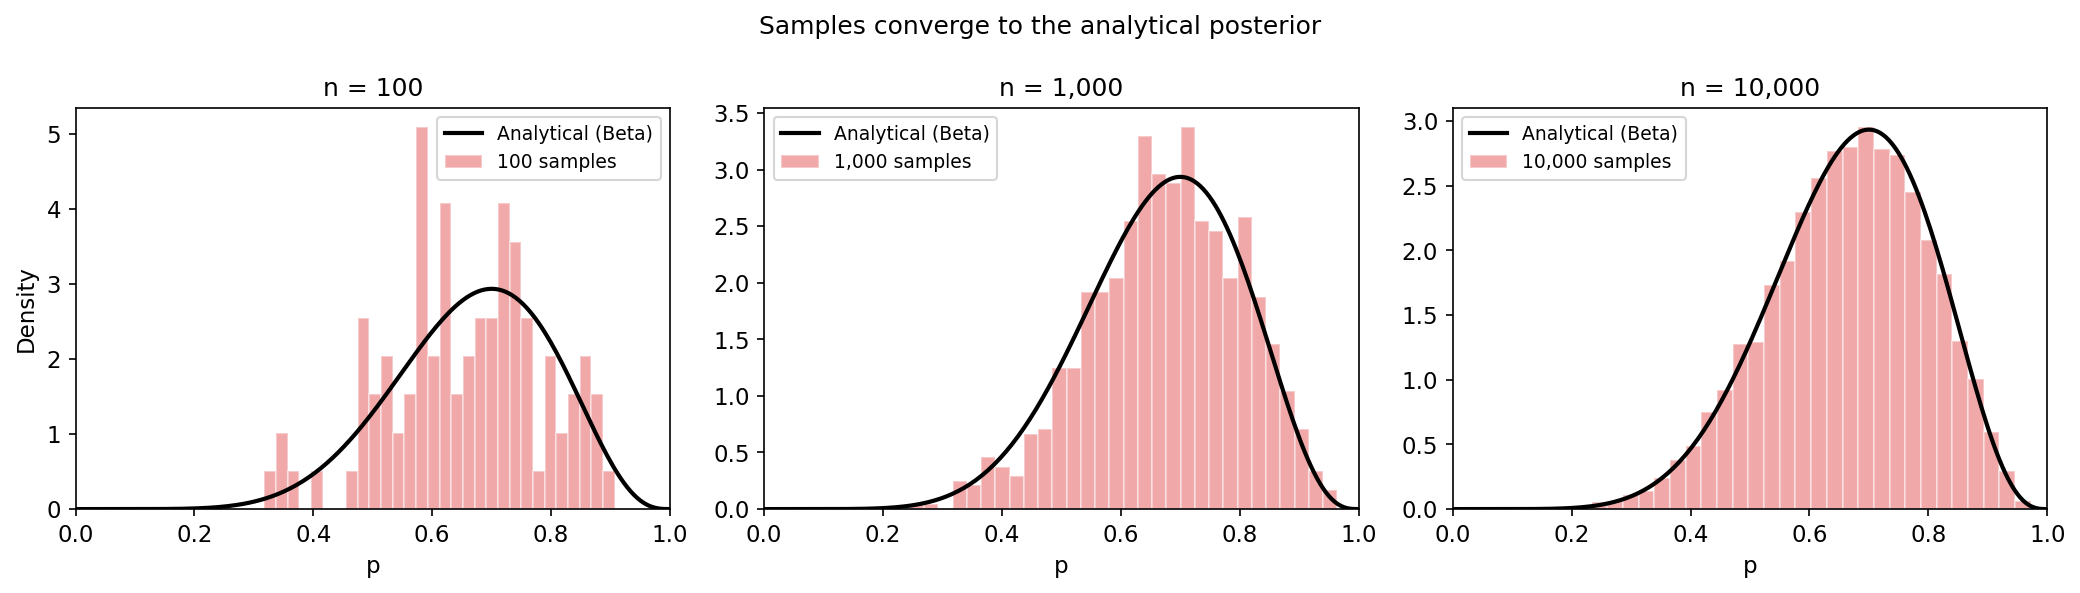

In [8]:
# Demonstrate sampling convergence
posterior = stats.beta(8, 4)
p_grid = np.linspace(0, 1, 200)
sample_sizes = [100, 1_000, 10_000]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rng_demo = np.random.default_rng(SEED)

for ax, n in zip(axes, sample_sizes):
    samples = posterior.rvs(size=n, random_state=rng_demo)

    ax.plot(p_grid, posterior.pdf(p_grid), "k-", linewidth=2, label="Analytical (Beta)")
    ax.hist(samples, bins=30, density=True, alpha=0.4,
            color=C_LIKELIHOOD, edgecolor="white", label=f"{n:,} samples")

    ax.set_title(f"n = {n:,}")
    ax.set_xlabel("p")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Density")
plt.suptitle("Samples converge to the analytical posterior", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Prior Predictive Simulation

A prior is a posterior that has not seen data. Sample from the prior, push through the generative model, and check whether the predictions look reasonable. Catches bad priors before wasting time on fitting.

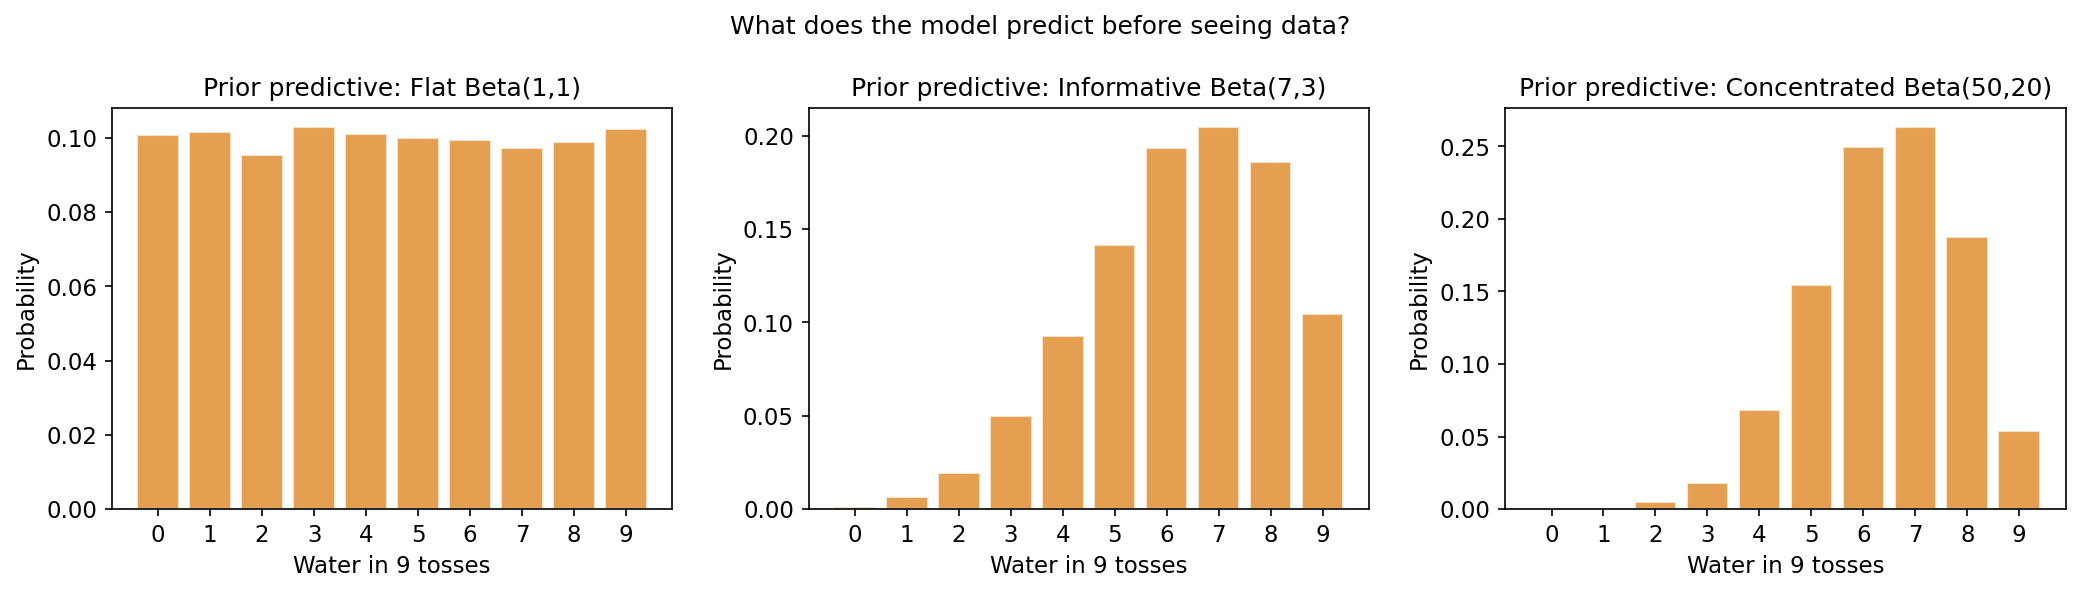

Flat prior: all outcomes equally likely (maximally uninformative).
Informative prior: clusters around 6-7 water (encodes geographic knowledge).
Concentrated prior: very peaked around 6-7 (strong prior, hard to overwhelm with data).


In [9]:
# Compare prior predictive distributions for different priors
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
n_tosses = 9
rng_prior = np.random.default_rng(SEED)

prior_configs = [
    ("Flat Beta(1,1)", 1, 1),
    ("Informative Beta(7,3)", 7, 3),
    ("Concentrated Beta(50,20)", 50, 20),
]

for ax, (name, a, b) in zip(axes, prior_configs):
    p_samples = stats.beta(a, b).rvs(size=N_SAMPLES, random_state=rng_prior)
    predicted = rng_prior.binomial(n=n_tosses, p=p_samples)

    counts = np.bincount(predicted, minlength=n_tosses + 1)
    probs = counts / counts.sum()
    ax.bar(range(n_tosses + 1), probs, color=C_ACCENT, alpha=0.7, edgecolor="white")
    ax.set_xlabel(f"Water in {n_tosses} tosses")
    ax.set_ylabel("Probability")
    ax.set_title(f"Prior predictive: {name}")
    ax.set_xticks(range(n_tosses + 1))

plt.suptitle("What does the model predict before seeing data?", fontsize=12)
plt.tight_layout()
plt.show()

print("Flat prior: all outcomes equally likely (maximally uninformative).")
print("Informative prior: clusters around 6-7 water (encodes geographic knowledge).")
print("Concentrated prior: very peaked around 6-7 (strong prior, hard to overwhelm with data).")

---

# Part 2: Applied Exercises with Slovenian Data

Same three-step posterior predictive workflow from Part 1, applied to real datasets.

In [10]:
# Load datasets
re = pd.read_csv(DATA_DIR / "sr2026_real_estate.csv", parse_dates=["date"])
forensic = pd.read_csv(DATA_DIR / "sr2026_forensic_audio.csv")
crime = pd.read_csv(DATA_DIR / "sr2026_crime.csv")
mun = pd.read_csv(DATA_DIR / "sr2026_municipality_panel.csv")

print(f"Real estate: {len(re):,} transactions, {re['year'].min()}-{re['year'].max()}")
print(f"Forensic audio: {len(forensic):,} recordings")
print(f"Crime: {len(crime):,} records, {crime['admin_unit'].nunique()} admin units")
print(f"Municipality panel: {len(mun):,} rows")

Real estate: 191,097 transactions, 2007-2025
Forensic audio: 200 recordings
Crime: 915 records, 61 admin units
Municipality panel: 424 rows


## Exercise 1: Real Estate Posterior Predictive

**Estimand:** How many of the next 50 Ljubljana apartment transactions will exceed 3,000 EUR/m2?

**Scientific model:** Each transaction is independent, with probability $p$ of exceeding the threshold. We learn $p$ from the most recent year's data, then predict next quarter's transactions.

**Method:** Posterior predictive via sampling. Compare full posterior vs point estimate prediction.

In [11]:
# Ljubljana apartments, most recent year
THRESHOLD = 3_000
lj_apt = re[
    (re["municipality"] == "LJUBLJANA")
    & (re["property_type"] == "apartment")
    & (re["price_per_m2"].notna())
]
latest_year = lj_apt["year"].max()
lj_recent = lj_apt[lj_apt["year"] == latest_year]

n_above = (lj_recent["price_per_m2"] > THRESHOLD).sum()
n_below = len(lj_recent) - n_above
print(f"Year {latest_year}: {n_above} above, {n_below} below {THRESHOLD:,} EUR/m2 "
      f"(n={len(lj_recent)}, p={n_above/len(lj_recent):.3f})")

Year 2025: 108 above, 5 below 3,000 EUR/m2 (n=113, p=0.956)


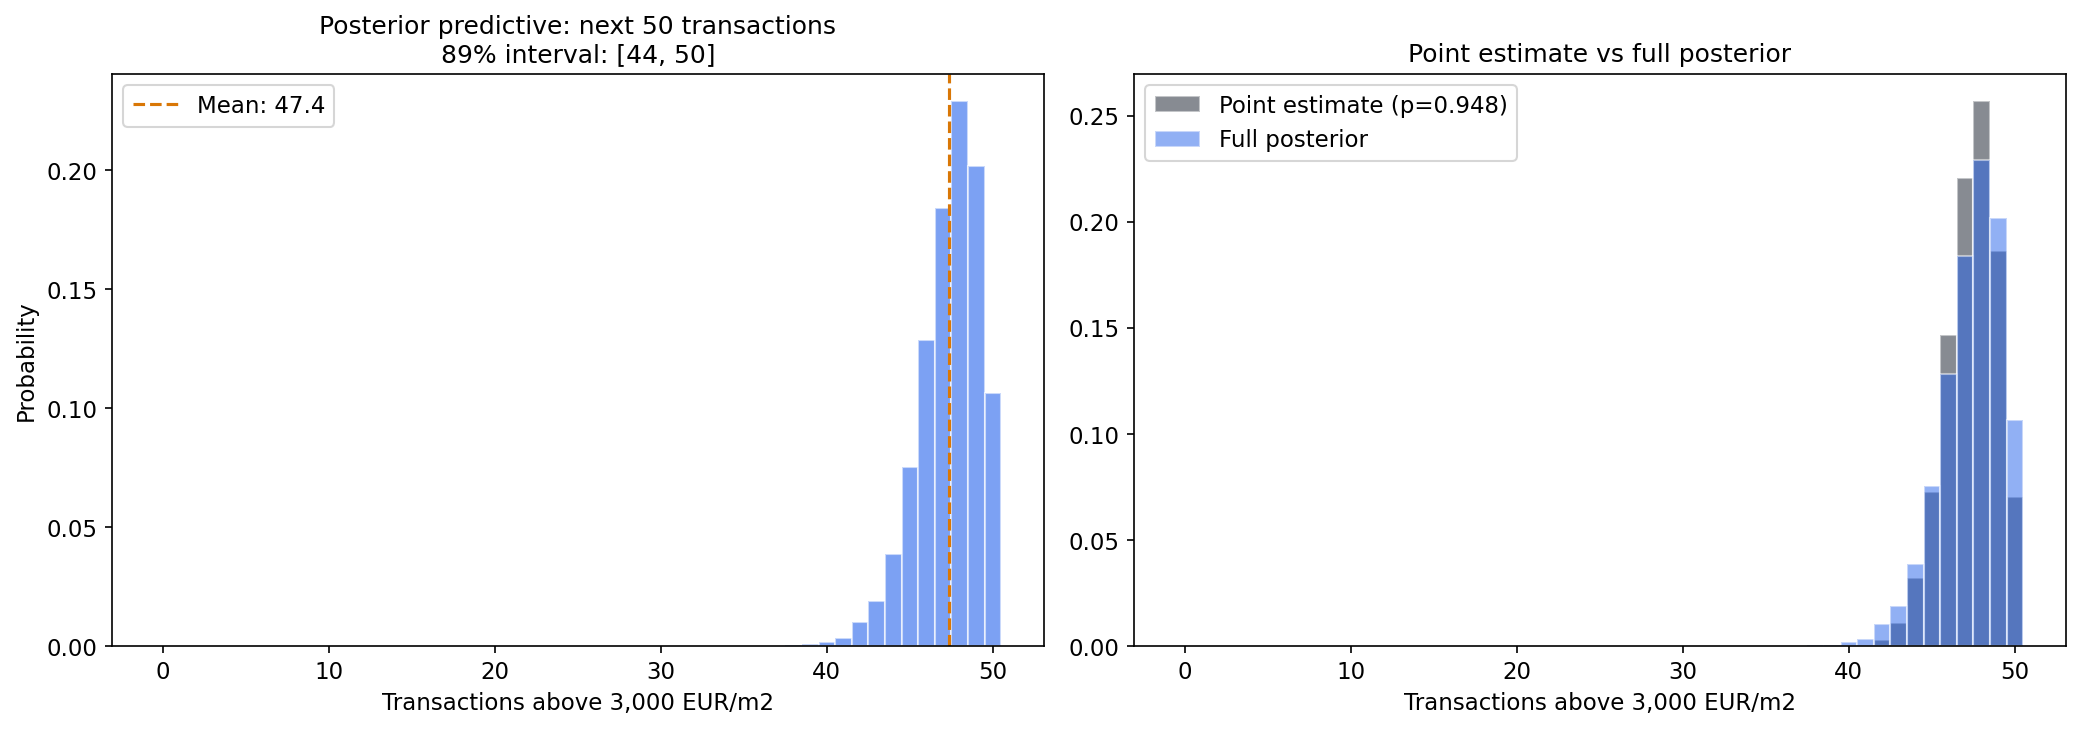

Full posterior std: 1.88
Point estimate std: 1.57
Ratio: 1.19x wider


In [12]:
# Posterior predictive: predict next 50 transactions
N_NEXT = 50
rng_e1 = np.random.default_rng(SEED)

posterior_re = stats.beta(n_above + 1, n_below + 1)
p_samples_re = posterior_re.rvs(size=N_SAMPLES, random_state=rng_e1)

# Full posterior predictive
full_pred_re = rng_e1.binomial(n=N_NEXT, p=p_samples_re)

# Point estimate predictive
p_hat = posterior_re.mean()
point_pred_re = rng_e1.binomial(n=N_NEXT, p=p_hat, size=N_SAMPLES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.arange(-0.5, N_NEXT + 1.5, 1)

# Left: posterior predictive
axes[0].hist(full_pred_re, bins=bins, density=True, alpha=0.6,
             color=C_POSTERIOR, edgecolor="white")
ci_lo, ci_hi = np.percentile(full_pred_re, 5.5), np.percentile(full_pred_re, 94.5)
axes[0].axvline(full_pred_re.mean(), color=C_ACCENT, linestyle="--", linewidth=1.5,
                label=f"Mean: {full_pred_re.mean():.1f}")
axes[0].set_title(f"Posterior predictive: next {N_NEXT} transactions\n"
                  f"89% interval: [{ci_lo:.0f}, {ci_hi:.0f}]")
axes[0].set_xlabel(f"Transactions above {THRESHOLD:,} EUR/m2")
axes[0].set_ylabel("Probability")
axes[0].legend()

# Right: point vs full comparison
axes[1].hist(point_pred_re, bins=bins, density=True, alpha=0.5,
             color=C_POINT, label=f"Point estimate (p={p_hat:.3f})", edgecolor="white")
axes[1].hist(full_pred_re, bins=bins, density=True, alpha=0.5,
             color=C_POSTERIOR, label="Full posterior", edgecolor="white")
axes[1].set_title("Point estimate vs full posterior")
axes[1].set_xlabel(f"Transactions above {THRESHOLD:,} EUR/m2")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Full posterior std: {full_pred_re.std():.2f}")
print(f"Point estimate std: {point_pred_re.std():.2f}")
print(f"Ratio: {full_pred_re.std() / point_pred_re.std():.2f}x wider")

## Exercise 2: Forensic Audio — Anomaly Prediction

**Estimand:** Given the observed proportion of anomalous features across recordings, how many anomalies should we expect in a new batch of 50 recordings?

**Scientific model:** Each recording independently passes or fails an anomaly test. The base rate depends on category (authentic recordings have low anomaly rates; manipulated ones have high rates). We estimate separate posteriors per category and compare their posterior predictive distributions.

**Method:** Posterior predictive per category. If the observed count in a new batch falls outside the authentic posterior predictive, it is evidence of manipulation.

In [13]:
# Use splice_candidates > 0 as a simple anomaly indicator
forensic["has_anomaly"] = (forensic["splice_candidates"] > 0).astype(int)

cat_stats = (
    forensic.groupby("category")
    .agg(n_total=("has_anomaly", "count"), n_anomalous=("has_anomaly", "sum"))
    .assign(n_clean=lambda df: df["n_total"] - df["n_anomalous"])
    .assign(obs_rate=lambda df: df["n_anomalous"] / df["n_total"])
    .sort_values("obs_rate")
)
print(cat_stats.to_string())

                            n_total  n_anomalous  n_clean  obs_rate
category                                                           
authentic                        70            6       64  0.085714
enf_injected_naive               21            2       19  0.095238
enf_injected_sophisticated       24            3       21  0.125000
tts_generated                    52            8       44  0.153846
spliced                          33           33        0  1.000000


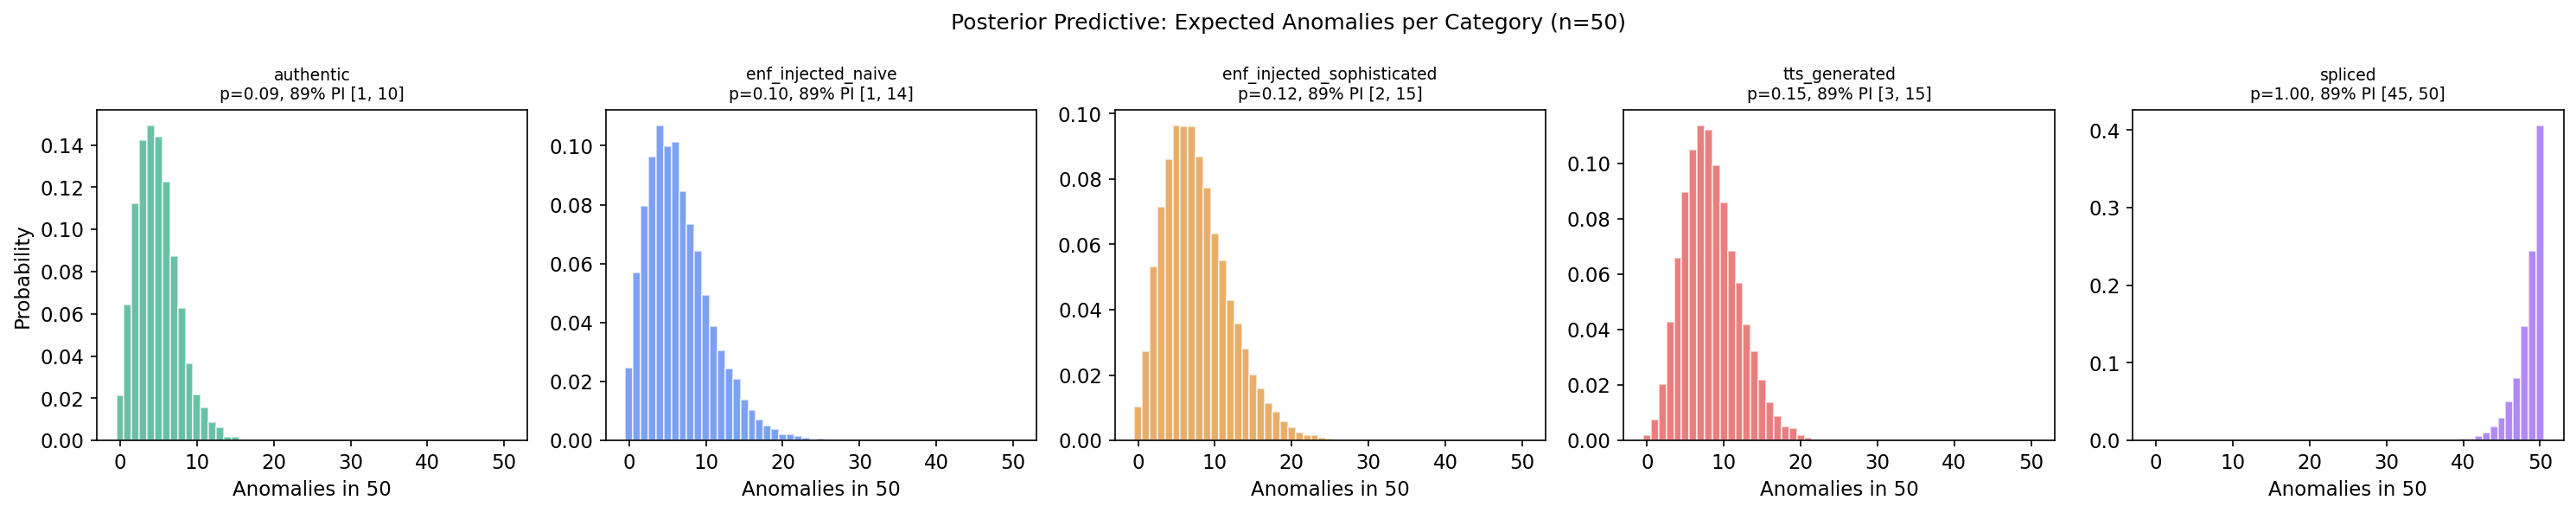

If a new batch of 'authentic' recordings shows anomaly counts in the spliced/injected range,
that is evidence the recordings are not what they claim to be.


In [14]:
# Posterior predictive per category: predict anomalies in next 50 recordings
N_NEW_RECORDINGS = 50
rng_e2 = np.random.default_rng(SEED)

fig, axes = plt.subplots(1, len(cat_stats), figsize=(4 * len(cat_stats), 4))
bins = np.arange(-0.5, N_NEW_RECORDINGS + 1.5, 1)

colors_cat = [C_DATA, C_POSTERIOR, C_ACCENT, C_LIKELIHOOD, "#7c3aed"]

for ax, ((cat, row), color) in zip(axes, zip(cat_stats.iterrows(), colors_cat)):
    n_anom = int(row["n_anomalous"])
    n_clean = int(row["n_clean"])

    # Posterior: Beta(n_anom + 1, n_clean + 1)
    post = stats.beta(n_anom + 1, n_clean + 1)
    p_samp = post.rvs(size=N_SAMPLES, random_state=rng_e2)
    pred = rng_e2.binomial(n=N_NEW_RECORDINGS, p=p_samp)

    ci_lo, ci_hi = np.percentile(pred, 5.5), np.percentile(pred, 94.5)

    ax.hist(pred, bins=bins, density=True, alpha=0.6, color=color, edgecolor="white")
    ax.set_title(f"{cat}\np={row['obs_rate']:.2f}, 89% PI [{ci_lo:.0f}, {ci_hi:.0f}]",
                 fontsize=9)
    ax.set_xlabel("Anomalies in 50")
    if ax == axes[0]:
        ax.set_ylabel("Probability")

plt.suptitle("Posterior Predictive: Expected Anomalies per Category (n=50)", fontsize=12)
plt.tight_layout()
plt.show()

print("If a new batch of 'authentic' recordings shows anomaly counts in the spliced/injected range,")
print("that is evidence the recordings are not what they claim to be.")

## Exercise 3: Small vs Large Sample Posteriors — Municipality Comparison

**Estimand:** $p_i$, the proportion of residential transactions above the national median price per municipality.

**Scientific model:** Municipalities vary in market activity. Ljubljana has thousands of transactions per year; small municipalities may have fewer than 20. We scope to 2022-2025 to compare municipalities under the same market regime. Pooling across 2007-2025 would conflate structural price trends with cross-sectional municipality differences.

**A02 property demonstrated:** "No minimum sample size" and "shape embodies the sample size."

In [15]:
# Compute proportion above national median per municipality (apartments, 2022+)
# Scoping to recent years avoids mixing structurally different market regimes.
MUN_YEAR_MIN = 2022
apartments = re[
    (re["property_type"] == "apartment")
    & (re["price_per_m2"].notna())
    & (re["year"] >= MUN_YEAR_MIN)
].copy()
national_median = apartments["price_per_m2"].median()
apartments["above_median"] = (apartments["price_per_m2"] > national_median).astype(int)

mun_counts = (
    apartments.groupby("municipality")
    .agg(n_total=("above_median", "count"), n_above=("above_median", "sum"))
    .assign(n_below=lambda df: df["n_total"] - df["n_above"])
    .assign(obs_p=lambda df: df["n_above"] / df["n_total"])
    .sort_values("n_total", ascending=False)
)

# Pick contrasting municipalities: largest, mid-size, smallest
largest = mun_counts.head(3).index.tolist()
smallest = mun_counts[mun_counts["n_total"] >= 5].tail(3).index.tolist()
selected = largest + smallest

print(f"National median price/m2 ({MUN_YEAR_MIN}+): {national_median:,.0f} EUR")
print(f"\nSelected municipalities ({MUN_YEAR_MIN}+):")
print(mun_counts.loc[selected].to_string())

National median price/m2 (2022+): 2,136 EUR

Selected municipalities (2022+):
              n_total  n_above  n_below     obs_p
municipality                                     
LJUBLJANA        3635     3388      247  0.932050
MARIBOR          1978      433     1545  0.218908
CELJE             718      257      461  0.357939
CERKVENJAK          5        0        5  0.000000
GORNJI GRAD         5        0        5  0.000000
KOBARID             5        1        4  0.200000


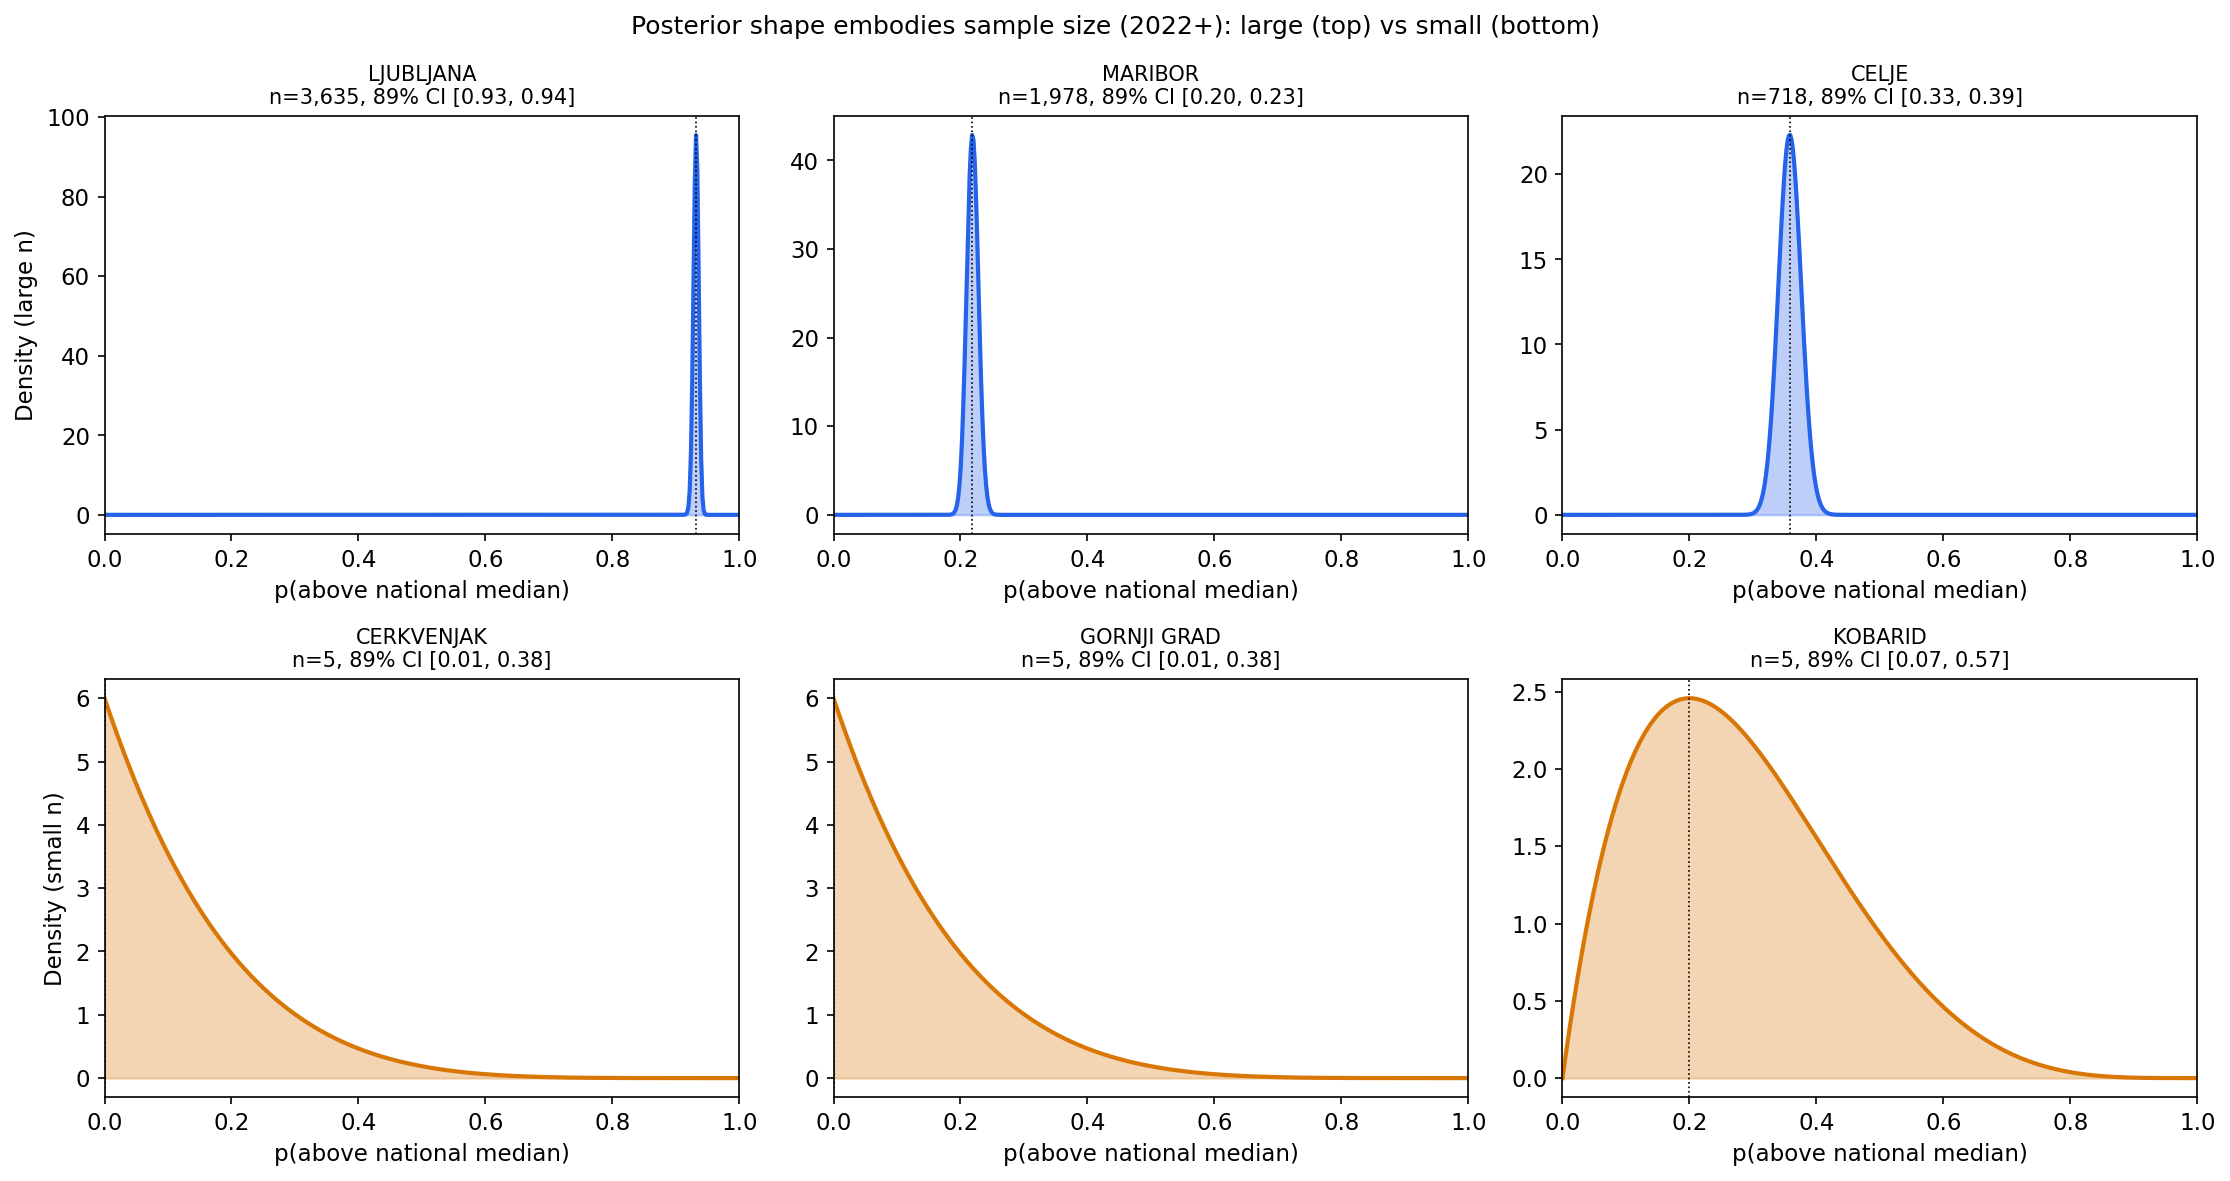

Top row: hundreds/thousands of recent transactions produce sharp posteriors.
Bottom row: a handful of transactions produce wide, honest posteriors.
Both are valid. The wide posterior is not a failure; it is an accurate representation of ignorance.


In [16]:
# Plot posteriors: large-sample municipalities vs small-sample municipalities
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
p_grid = np.linspace(0, 1, 500)

for idx, mun_name in enumerate(selected):
    row_idx = idx // 3
    col_idx = idx % 3
    ax = axes[row_idx, col_idx]

    row = mun_counts.loc[mun_name]
    n_a, n_b = int(row["n_above"]), int(row["n_below"])

    post = stats.beta(n_a + 1, n_b + 1)
    ci_lo, ci_hi = post.ppf(0.055), post.ppf(0.945)

    ax.fill_between(p_grid, post.pdf(p_grid), alpha=0.3,
                    color=C_POSTERIOR if row_idx == 0 else C_ACCENT)
    ax.plot(p_grid, post.pdf(p_grid), linewidth=2,
            color=C_POSTERIOR if row_idx == 0 else C_ACCENT)
    ax.axvline(row["obs_p"], color="black", linestyle=":", linewidth=0.8)

    ax.set_title(f"{mun_name}\nn={int(row['n_total']):,}, "
                 f"89% CI [{ci_lo:.2f}, {ci_hi:.2f}]", fontsize=10)
    ax.set_xlabel("p(above national median)")
    ax.set_xlim(0, 1)

axes[0, 0].set_ylabel("Density (large n)")
axes[1, 0].set_ylabel("Density (small n)")

plt.suptitle(f"Posterior shape embodies sample size ({MUN_YEAR_MIN}+): large (top) vs small (bottom)",
             fontsize=12)
plt.tight_layout()
plt.show()

print("Top row: hundreds/thousands of recent transactions produce sharp posteriors.")
print("Bottom row: a handful of transactions produce wide, honest posteriors.")
print("Both are valid. The wide posterior is not a failure; it is an accurate representation of ignorance.")

## Exercise 4: Crime Rate Prediction (Poisson Posterior Predictive)

**Estimand:** How many crimes should we expect next year in each administrative unit?

**Scientific model:** Crime counts follow a Poisson process with rate $\lambda$. We estimate $\lambda$ from historical data using Gamma-Poisson conjugacy, then predict next year's count via posterior predictive sampling.

**Method:** Sample $\lambda$ from $\text{Gamma}(\alpha + S, \beta + n)$, simulate $\text{Poisson}(\lambda)$ for each sample.

In [17]:
# Posterior predictive for crime counts
PRIOR_ALPHA = 2.0
PRIOR_BETA = 0.001
rng_e4 = np.random.default_rng(SEED)

units = crime["admin_unit"].unique()
unit_summaries = []

for unit in sorted(units):
    unit_data = crime[crime["admin_unit"] == unit]["crime_count"]
    n_obs = len(unit_data)
    total = unit_data.sum()

    # Posterior: Gamma(alpha + S, beta + n)
    post_alpha = PRIOR_ALPHA + total
    post_beta = PRIOR_BETA + n_obs

    # Sample lambda, then predict
    lambda_samples = rng_e4.gamma(post_alpha, scale=1 / post_beta, size=N_SAMPLES)
    pred_counts = rng_e4.poisson(lambda_samples)

    ci_lo, ci_hi = np.percentile(pred_counts, 5.5), np.percentile(pred_counts, 94.5)
    last_year = unit_data.iloc[-1]

    unit_summaries.append({
        "unit": unit,
        "n_years": n_obs,
        "mean_obs": unit_data.mean(),
        "last_year": last_year,
        "pred_mean": pred_counts.mean(),
        "pred_ci_lo": ci_lo,
        "pred_ci_hi": ci_hi,
    })

summary_df = pd.DataFrame(unit_summaries).sort_values("mean_obs", ascending=False)
print("Posterior predictive: expected crime count next year\n")
for _, row in summary_df.iterrows():
    print(f"  {row['unit']:30s}  last year: {row['last_year']:6,.0f}  "
          f"predicted: {row['pred_mean']:6,.0f}  "
          f"89% PI: [{row['pred_ci_lo']:6,.0f}, {row['pred_ci_hi']:6,.0f}]")

Posterior predictive: expected crime count next year

  LJUBLJANA                       last year: 35,174  predicted: 39,862  89% PI: [39,530, 40,190]
  MARIBOR                         last year:  7,422  predicted:  9,660  89% PI: [ 9,497,  9,824]
  CELJE                           last year:  4,148  predicted:  4,734  89% PI: [ 4,620,  4,846]
  KRANJ                           last year:  4,376  predicted:  4,372  89% PI: [ 4,264,  4,480]
  NOVO MESTO                      last year:  4,683  predicted:  4,247  89% PI: [ 4,141,  4,353]
  DOMŽALE                         last year:  4,023  predicted:  3,930  89% PI: [ 3,827,  4,031]
  KOPER                           last year:  3,323  predicted:  3,561  89% PI: [ 3,463,  3,660]
  PTUJ                            last year:  2,337  predicted:  3,078  89% PI: [ 2,986,  3,171]
  MURSKA SOBOTA                   last year:  1,861  predicted:  2,829  89% PI: [ 2,743,  2,917]
  NOVA GORICA                     last year:  2,488  predicted:  2,535  8

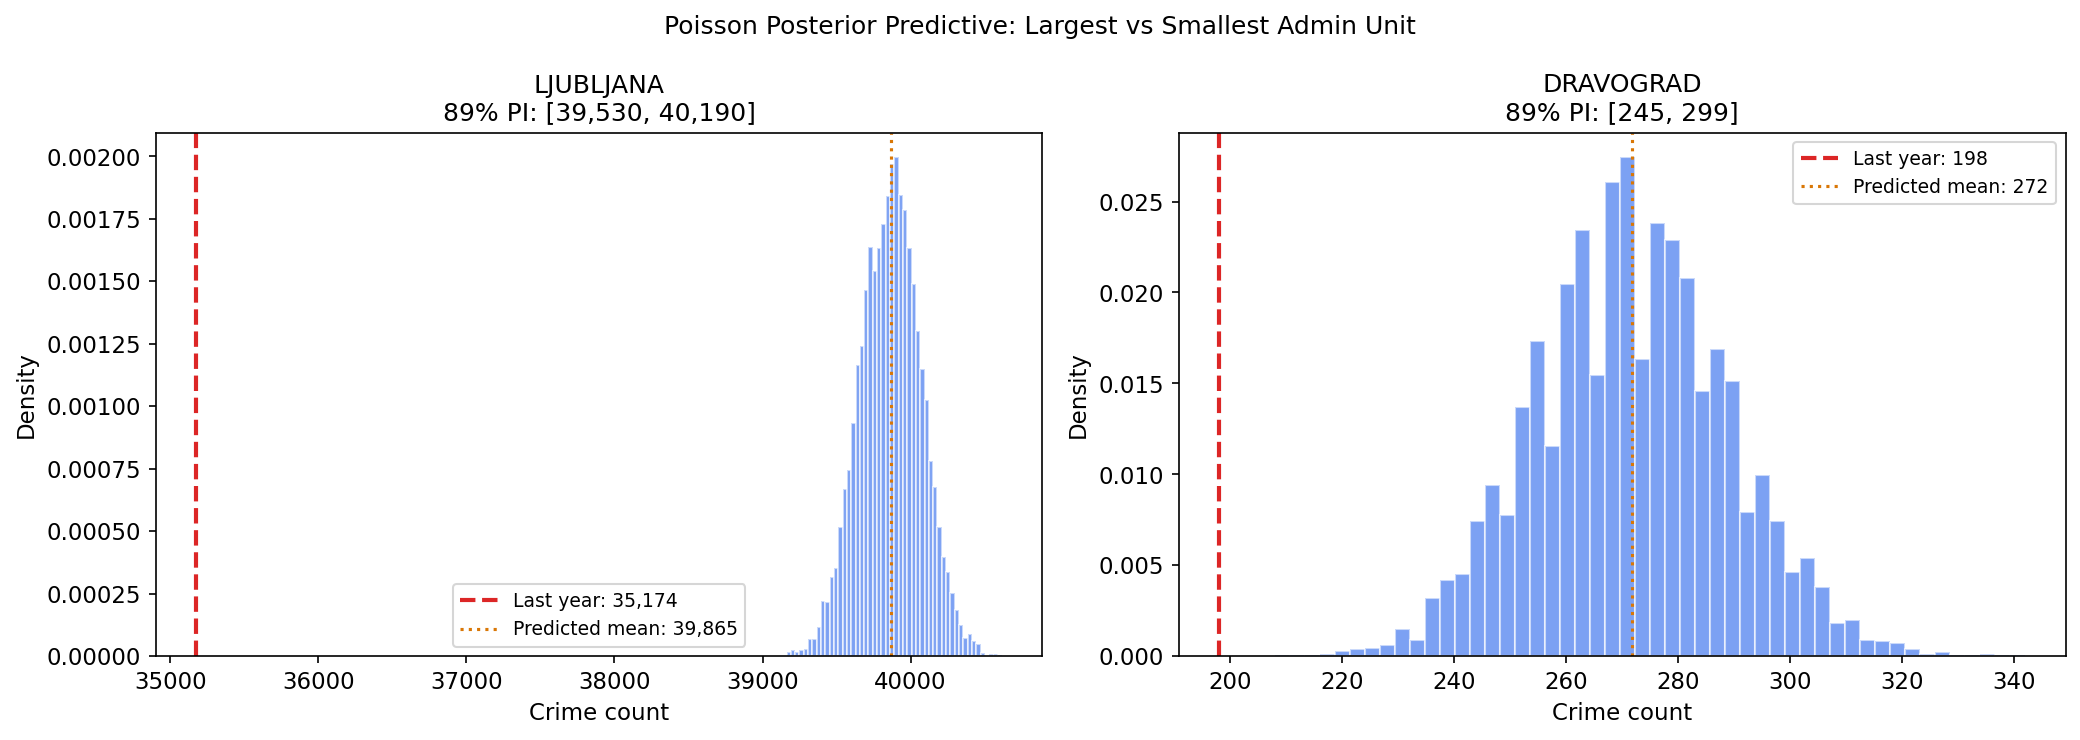

In [18]:
# Visualize: posterior predictive for the largest and smallest units
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

selected_rows = [summary_df.iloc[0], summary_df.iloc[-1]]
for ax, row in zip(axes, selected_rows):
    unit_data = crime[crime["admin_unit"] == row["unit"]]["crime_count"]
    n_obs = len(unit_data)
    total = unit_data.sum()

    post_alpha = PRIOR_ALPHA + total
    post_beta = PRIOR_BETA + n_obs

    rng_viz = np.random.default_rng(SEED)
    lambda_samp = rng_viz.gamma(post_alpha, scale=1 / post_beta, size=N_SAMPLES)
    pred = rng_viz.poisson(lambda_samp)

    ax.hist(pred, bins=50, density=True, alpha=0.6, color=C_POSTERIOR, edgecolor="white")
    ax.axvline(row["last_year"], color=C_LIKELIHOOD, linewidth=2, linestyle="--",
               label=f"Last year: {row['last_year']:,.0f}")
    ax.axvline(pred.mean(), color=C_ACCENT, linewidth=1.5, linestyle=":",
               label=f"Predicted mean: {pred.mean():,.0f}")
    ax.set_title(f"{row['unit']}\n89% PI: [{row['pred_ci_lo']:,.0f}, {row['pred_ci_hi']:,.0f}]")
    ax.set_xlabel("Crime count")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Poisson Posterior Predictive: Largest vs Smallest Admin Unit", fontsize=12)
plt.tight_layout()
plt.show()

## Exercise 5: Point Estimate vs Full Posterior — Price Index Illustration

**Estimand:** National average proportion of above-median transactions across municipalities (2022+).

**Scientific model:** Each municipality has its own $p_i$. The national average is $\bar{p} = \frac{1}{M}\sum_i p_i$. If we compute $\bar{p}$ from point estimates (posterior means), we underestimate uncertainty. The correct approach: for each posterior draw, compute $\bar{p}$, then summarize.

**A02 lesson demonstrated:** "Summarize last." This is the price index mistake from the lecture notes.

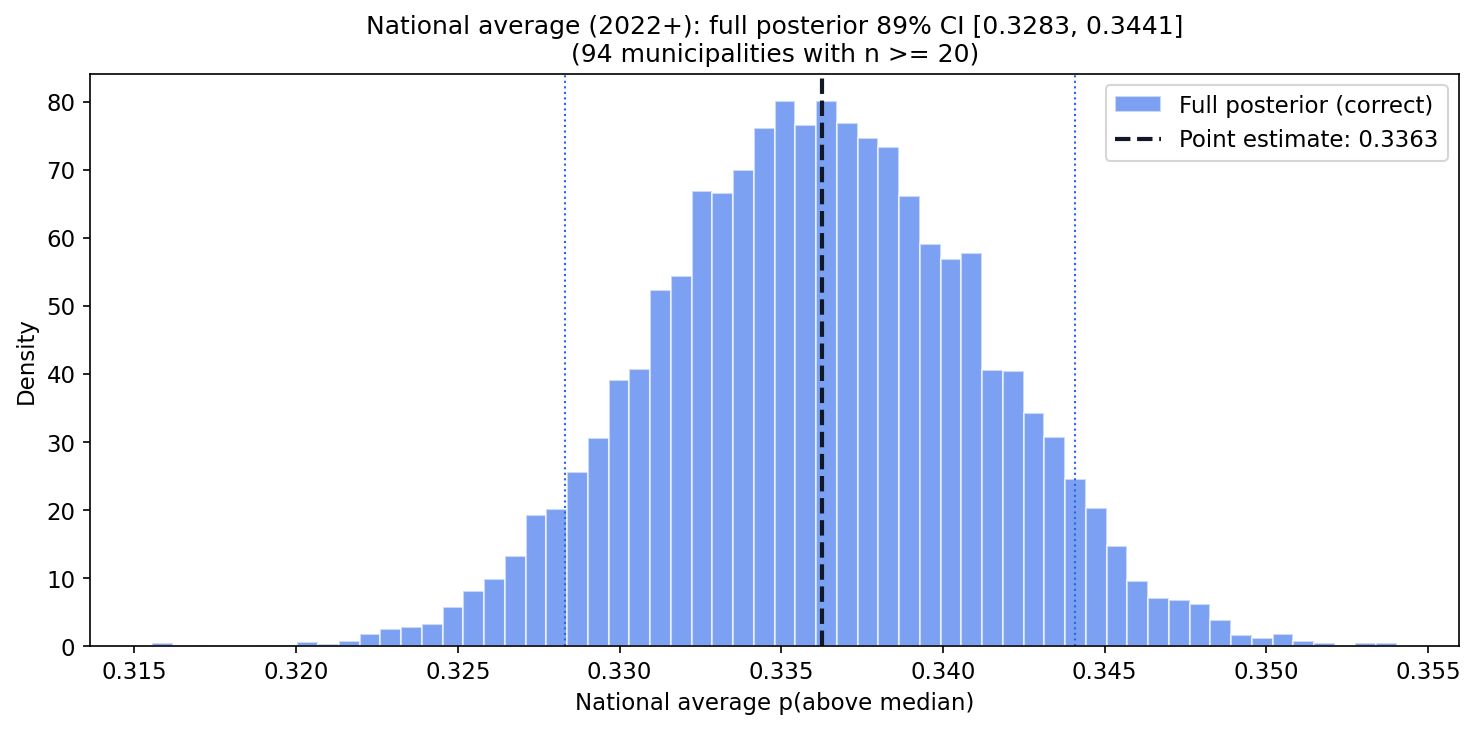

Full posterior mean: 0.3362, std: 0.0050
Point estimate:      0.3363, std: 0 (no uncertainty!)

The point estimate gives the same central value but zero uncertainty.
In CRR3 risk reporting, this underestimates risk bands.


In [19]:
# Select municipalities with at least 20 recent transactions for meaningful posteriors
# mun_counts is already scoped to 2022+ from Exercise 3
mun_valid = mun_counts[mun_counts["n_total"] >= 20].copy()
n_mun = len(mun_valid)
rng_e5 = np.random.default_rng(SEED)

# For each municipality, draw N_SAMPLES from its Beta posterior
# Shape: (n_municipalities, N_SAMPLES)
p_draws = np.zeros((n_mun, N_SAMPLES))
for i, (mun_name, row) in enumerate(mun_valid.iterrows()):
    post = stats.beta(int(row["n_above"]) + 1, int(row["n_below"]) + 1)
    p_draws[i, :] = post.rvs(size=N_SAMPLES, random_state=rng_e5)

# CORRECT: compute national average for each draw, then summarize
national_avg_full = p_draws.mean(axis=0)  # average across municipalities per draw

# WRONG: take posterior mean per municipality, then average
point_estimates = np.array([
    stats.beta(int(row["n_above"]) + 1, int(row["n_below"]) + 1).mean()
    for _, row in mun_valid.iterrows()
])
national_avg_point = point_estimates.mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(national_avg_full, bins=60, density=True, alpha=0.6,
        color=C_POSTERIOR, edgecolor="white", label="Full posterior (correct)")

# The point estimate is a single number — show as a vertical line
ax.axvline(national_avg_point, color=C_POINT, linewidth=2, linestyle="--",
           label=f"Point estimate: {national_avg_point:.4f}")

ci_lo, ci_hi = np.percentile(national_avg_full, 5.5), np.percentile(national_avg_full, 94.5)
ax.axvline(ci_lo, color=C_POSTERIOR, linewidth=1, linestyle=":")
ax.axvline(ci_hi, color=C_POSTERIOR, linewidth=1, linestyle=":")

ax.set_xlabel("National average p(above median)")
ax.set_ylabel("Density")
ax.set_title(f"National average ({MUN_YEAR_MIN}+): full posterior 89% CI [{ci_lo:.4f}, {ci_hi:.4f}]\n"
             f"({n_mun} municipalities with n >= 20)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Full posterior mean: {national_avg_full.mean():.4f}, std: {national_avg_full.std():.4f}")
print(f"Point estimate:      {national_avg_point:.4f}, std: 0 (no uncertainty!)")
print(f"\nThe point estimate gives the same central value but zero uncertainty.")
print("In CRR3 risk reporting, this underestimates risk bands.")

---

# Key Takeaways

1. **Beta is counting at the limit.** The d4-to-continuous progression shows the Beta distribution is not an arbitrary choice. It is the exact result of the A01 counting logic on a continuous parameter space.

2. **Density is not probability.** Density can exceed 1. Area under the curve gives probability. This matters when reading PyMC trace plots and communicating results to non-technical stakeholders.

3. **Posterior predictive is the central tool.** Sample from posterior, push through generative model, collect predictions. Three steps. Applied to real estate transaction forecasting, forensic anomaly detection, and crime rate prediction.

4. **Summarize last.** Computing the national price index from point estimates (Exercise 5) discards parameter uncertainty. Process the full distribution through all transformations, then summarize at the end. The CRR3 compliance case makes this non-negotiable.

5. **Shape tells the story.** Ljubljana's razor-sharp posterior vs a small municipality's broad posterior (Exercise 3) shows that the posterior honestly encodes what the data say. No minimum sample size required.

6. **Prior predictive checks catch bad priors.** Before fitting any model, simulate from the prior and verify the predictions are plausible. Bridge to [[Lecture A03]].

**Next:** [[Lecture A03]] introduces linear regression and the full `pm.sample()` workflow for models without analytical posteriors.